# Predicting the S&P 500

## Load packages and import the data 

In [302]:
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.metrics import precision_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit



We will be developing the model and initially testing on the S&P 500. This stock measures the performance of the 500 leading large-cap U.S. companies. Large cap means that only companies with a market capitalization above $10 billion are included in the choosing for the 500 companies.

In [303]:
sp500 = yf.Ticker('^GSPC')
sp500 = sp500.history(period="max")

In [304]:
del sp500['Dividends']
del sp500['Stock Splits']
sp500.head()

,Open,High,Low,Close,Volume
Date,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0


`Open` represents the initial valuation of the S&P 500 on any given day. `High` and `Low` represent the highest and lowest value during the day, and `Close` is the final value.

### Visualize the growth of the S&P 500

Out of curiousity, I added four dates from recent history.

1. Feburary 19th, 2020, the case total in Hong Kong was 65, with two confirmed deaths. Iran had also announced 2 confirmed cases. 

2. The launch of Chat GPT on November 30th, 2022, potentially signifying the AI Boom. 

3. Finally, the day known as "Liberation Day" when President Trump announced a 10% tariff on nearly all imports. The S&P 500 suffered its worst two-day drop in 75 years.

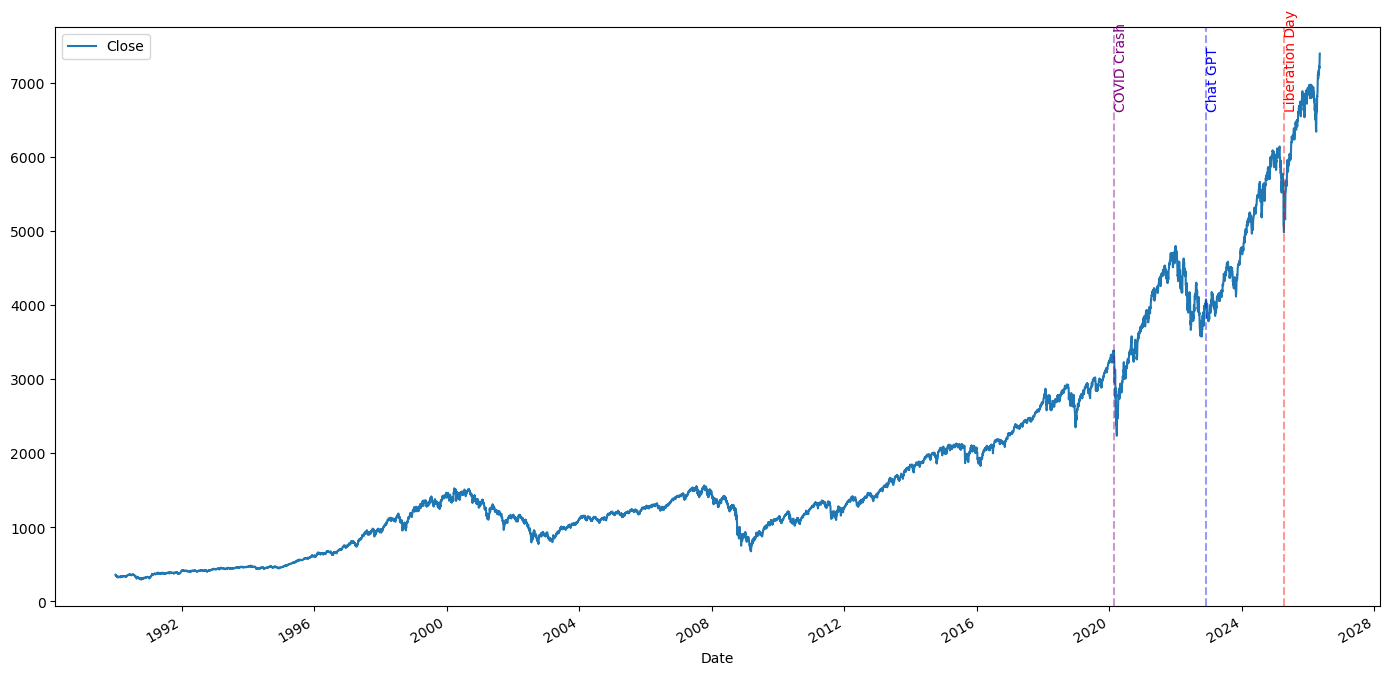

In [305]:
ax = sp500.loc["1990-01-01":].plot.line(y="Close", figsize=(14,7))

events = {
    "COVID Crash": ("2020-02-19", "purple"),
    "Chat GPT": ("2022-11-30", "blue"),
    "Liberation Day": ("2025-04-11", "red")
}

for label, (date, color) in events.items():
    ax.axvline(pd.Timestamp(date),
               color=color,
               linestyle="--",
               alpha=0.4)

    ax.text(pd.Timestamp(date),
            sp500["Close"].max().max()*0.9,
            label,
            rotation=90,
            color=color)

plt.tight_layout()
plt.show()

Now we define the target, which is a dummy column. One means the following day closed greater than the current day. Zero means the S&P devalued or didn't change from the current day at closing. 

In [306]:
sp500['Tomorrow'] = sp500["Close"].shift(-1)
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)
sp500.head()

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0


Now only consider more recent data, from 1990 to current day. 

In [307]:
sp500 = sp500.loc["1990-01-01":].copy()

## Random Forest Model

We will develop a more sophisticated way to make predictions on the stock market later, for now our train set will be all data besides the last 100 days. The test set is the last 100 days.

In [308]:
model = RandomForestClassifier(n_estimators = 100, min_samples_split = 100, random_state = 1)

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ['Close', 'Volume', 'Open', 'High', 'Low']
model.fit(train[predictors], train['Target'])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [309]:
preds = model.predict(test[predictors])
preds = pd.Series(preds, index = test.index)

In [310]:
print(precision_score(test['Target'], preds))
print(accuracy_score(test['Target'], preds))

0.627906976744186
0.58


This precision score is actually great, along with accuracy, but this is only the last 100 days. This should give us no confidence in the model as a whole. To demonstrate this we have to be able to back test our data. This means testing data on new unseen data, that is specifically in the future from the seen data. We can back test many years with the following set up below.

## Back testing

To gain more confidence in our model predictions, the two functions are defined.

1. `predict` is a function makes predictions from a model and returns a dataframe with the target and predictions
* Inputs: train set, test set, features/predictors, and a model
* Outputs: true target and predictions, as dataframe

2. `backtest` trains a model that makes predictions only on data in the future. It works by looping through the data with a start and a step. The start is 10 years (there are about 250 trading days in a year) of data, and the step is one year. For the first iteration **i = start**. Through each loop the train data is fit on data only up to i, and the test data is the following year. Thus, when the function ends we have fit a model once for each year after 10 years of the market opening, and make predictions from the following year. Finally, we concatenate the predictions and the targets together, with help from `predict`.
* Inputs: The data frame, the model, feature/predictor columns as a list, start and step.
* Outputs: Predictions from each year of the back test in a data frame.



In [311]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index = test.index, name = "Predictions")
    combined = pd.concat([test["Target"], preds], axis = 1)
    return combined

def backtest(data, model, predictors, start = 2500, step = 250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [312]:
predictions = backtest(sp500, model, predictors)
predictions.head()

,Target,Predictions
Date,,
1999-11-22 00:00:00-05:00,0,0
1999-11-23 00:00:00-05:00,1,0
1999-11-24 00:00:00-05:00,0,0
1999-11-26 00:00:00-05:00,0,0
1999-11-29 00:00:00-05:00,0,0


We can now view the proportion of days that we predicted the S&P will close higher, and the true proportions. 

In [313]:
comparison = pd.DataFrame({
    "Predictions": predictions["Predictions"].value_counts() / predictions.shape[0],
    "Target": predictions["Target"].value_counts() / predictions.shape[0]
})

print(comparison)

   Predictions    Target
0     0.596394  0.462509
1     0.403606  0.537491


This also gives us a baseline accuracy to aim for, 55%, the rough percent of days the stock market was valued higher at close the following day. 

In [314]:
print(precision_score(predictions["Target"], predictions["Predictions"]))
print(accuracy_score(predictions["Target"], predictions["Predictions"]))

0.5312732688011914
0.4877535687453043


The model currently does worse than waking up guessing saying market will go up everyday.

# Rolling Averages

We can add rolling averages, which will create a rolling average of the S&P over the time horizon. The time horizons choosen are 2, 5, 60, 250, and 1000 days. We will have a column for the ratio of each close to the average, and a trend column which will track the number of days the stock market went up over the horizon.

In [315]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]

    trend_column = f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()['Target']

    new_predictors += [ratio_column, trend_column]

In [316]:
sp500 = sp500.dropna()

In [317]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state =1)

In [318]:
def predict_proba(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >= 0.6] = 1
    preds[preds < 0.6] = 0
    preds = pd.Series(preds, index = test.index, name = "Predictions")
    combined = pd.concat([test["Target"], preds], axis = 1)
    return combined

def backtest_proba(data, model, predictors, start = 2500, step = 250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict_proba(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

`new_predictors` has only the ratio columns and the trend columns.

In [319]:
predictions = backtest_proba(sp500, model, new_predictors)

In [320]:
predictions["Predictions"].value_counts()

Predictions
0.0    4778
1.0     876
Name: count, dtype: int64

In [321]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5753424657534246

# Improving the Model

To try to improve the model, we are going to add rolling averages from the stock ETA. This stock has holdings in mid to large cap markets in Eurasia. The idea with adding this data is the Europe and some other international markets might track some variation in the S&P 500.

In [322]:
efa = yf.Ticker('efa')
efa = efa.history(period="max")
del efa['Dividends']
del efa['Stock Splits']
del efa['Capital Gains']
efa.head()

efa['Open_efa'] = efa['Open']
efa['Close_efa'] = efa['Close']
efa['High_efa'] = efa['High']
efa['Low_efa'] = efa['Low']
efa['Volume_efa'] = efa['Volume']

for horizon in horizons:
    rolling_averages = efa.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}_efa"
    efa[ratio_column] = efa["Close"] / rolling_averages["Close"]

    new_predictors += [ratio_column, trend_column]

sp500 = pd.concat([efa, sp500], axis=1)

<positron-console-cell-322>:22: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.


In [323]:
sp500 = sp500.dropna()
sp500.head()

,Open,High,Low,Close,Volume,Open_efa,Close_efa,High_efa,Low_efa,Volume_efa,...,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2005-08-19 00:00:00-04:00,30.265712,30.353059,30.222039,30.254793,920400.0,30.265712,30.254793,30.353059,30.222039,920400.0,...,1.000283,1.0,0.997770,3.0,1.003422,36.0,1.034872,144.0,1.147759,520.0
2005-08-22 00:00:00-04:00,30.544132,30.680612,30.467704,30.587805,1383500.0,30.544132,30.587805,30.680612,30.467704,1383500.0,...,1.000827,2.0,1.001411,3.0,1.004752,36.0,1.036175,144.0,1.149614,521.0
2005-08-23 00:00:00-04:00,30.325770,30.489545,30.298474,30.456791,1682000.0,30.325770,30.456791,30.489545,30.298474,1682000.0,...,0.998303,1.0,0.998304,3.0,1.001089,35.0,1.032270,143.0,1.145658,521.0
2005-08-24 00:00:00-04:00,30.353052,30.429482,30.134686,30.134686,1171500.0,30.353052,30.134686,30.429482,30.134686,1171500.0,...,0.996704,0.0,0.993480,2.0,0.994265,35.0,1.025134,142.0,1.138065,521.0
2005-08-25 00:00:00-04:00,30.282088,30.363975,30.227495,30.249332,1069700.0,30.282088,30.249332,30.363975,30.227495,1069700.0,...,1.001148,1.0,0.996853,3.0,0.996411,35.0,1.027095,143.0,1.140591,522.0


In [324]:
predictions = backtest_proba(sp500, model, new_predictors)
predictions["Predictions"].value_counts()
precision_score(predictions["Target"], predictions["Predictions"])

0.5676855895196506

In [ ]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="`sklearn.utils.parallel.delayed` should be used"
)

param_grid = {
    "n_estimators": [100, 200, 500], 
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestClassifier(
    random_state=1,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="precision",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(sp500[new_predictors], sp500["Target"]);

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


In [ ]:
best_model = grid_search.best_estimator_

predictions = backtest_proba(
    data=sp500,
    model=best_model,
    predictors=predictors
)

precision = precision_score(
    predictions["Target"],
    predictions["Predictions"]
)

print("\nBacktest Precision:")
print(precision)


Backtest Precision:
0.5486381322957199


# Conclusion

From our first random forest model, the precision score was, 0.531. Now with a grid search and some more feature engineering we were able to get a precision score of nearly 0.55. 